# Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

# Load Dataset

In [34]:
df = pd.read_csv(
    r"C:\Users\sanke\OneDrive\Documents\Fraud Detection System\Dataset\fraudTest.csv",
    low_memory=False
)

In [35]:
df.shape

(90000, 22)

# Basic EDA

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  90000 non-null  object 
 1   cc_num                 90000 non-null  float64
 2   merchant               90000 non-null  object 
 3   category               90000 non-null  object 
 4   amt                    90000 non-null  float64
 5   first                  90000 non-null  object 
 6   last                   90000 non-null  object 
 7   gender                 90000 non-null  object 
 8   street                 90000 non-null  object 
 9   city                   90000 non-null  object 
 10  state                  90000 non-null  object 
 11  zip                    90000 non-null  int64  
 12  lat                    90000 non-null  float64
 13  long                   90000 non-null  float64
 14  city_pop               90000 non-null  int64  
 15  jo

In [37]:
df['is_fraud'].value_counts()

is_fraud
0    89632
1      368
Name: count, dtype: int64

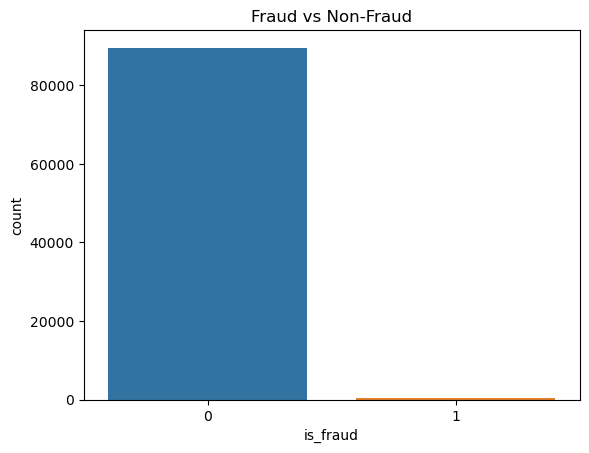

In [38]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# Data Cleaning

In [39]:
df = df.drop(['first','last','street','trans_num','cc_num'], axis=1)

# Encode Categorical Variables

In [40]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

C:\Users\sanke\AppData\Local\Temp\ipykernel_6748\3602715783.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
C:\Users\sanke\AppData\Local\Temp\ipykernel_6748\3602715783.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['dob'] = pd.to_datetime(df['dob'])


# Feature Engineering

In [41]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = df['trans_date_trans_time'].dt.weekday >= 5

df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Distance Calculation

In [42]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df['distance_km'] = df.apply(
    lambda x: haversine(x['lat'], x['long'], x['merch_lat'], x['merch_long']),
    axis=1
)

# Drop Unused Columns

In [43]:
df = df.drop(['trans_date_trans_time','dob','lat','long','merch_lat','merch_long'], axis=1)

# Encoding Categorical Features

In [44]:
le_merchant = LabelEncoder()
le_category = LabelEncoder()
le_city = LabelEncoder()
le_state = LabelEncoder()
le_job = LabelEncoder()

df['merchant'] = le_merchant.fit_transform(df['merchant'])
df['category'] = le_category.fit_transform(df['category'])
df['city'] = le_city.fit_transform(df['city'])
df['state'] = le_state.fit_transform(df['state'])
df['job'] = le_job.fit_transform(df['job'])

df['gender'] = df['gender'].map({'M':1,'F':0})

# Train Test Split

In [45]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle Imbalanced Data (SMOTE)

In [46]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Feature Scaling

In [47]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

# Train Model (XGBoost)

In [48]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss"
)

model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluate

In [49]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17926
           1       0.51      0.93      0.66        74

    accuracy                           1.00     18000
   macro avg       0.76      0.96      0.83     18000
weighted avg       1.00      1.00      1.00     18000



# Save Model + Encoders

In [50]:
joblib.dump(model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

joblib.dump(le_merchant, "merchant_encoder.pkl")
joblib.dump(le_category, "category_encoder.pkl")
joblib.dump(le_city, "city_encoder.pkl")
joblib.dump(le_state, "state_encoder.pkl")
joblib.dump(le_job, "job_encoder.pkl")

['job_encoder.pkl']